# Analisis de conjunto de datos de siniestros

Análisis de conjunto de datos de siniestros en Montevideo que provee la Intendencia de Montevideo de manera pública, año 2022:
[https://ckan.montevideo.gub.uy/dataset/base-anual-de-personas-lesionadas-en-siniestros-de-transito]

In [1]:
%load_ext autoreload
%autoreload 2

In [17]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from unidecode import unidecode
import os
import sys

import warnings
warnings.filterwarnings("ignore")

sys.path.append(os.path.abspath(".."))
from utils import *
import contextily as ctx

## Descarga y carga de los datos

In [3]:
descargar_datasets(datasets="siniestros", carpeta="../datasets")

Descargando: siniestros2022.csv...
✅ siniestros2022.csv guardado.

Descargando: metadata-siniestros.txt...
✅ metadata-siniestros.txt guardado.


Los datasets se encuentran disponibles en la ruta:  /home/bruno/Escritorio/REPO PROYECTO GRAFOS/analisis_datasets/../datasets


Levantamos el dataset:

In [4]:
path = "../datasets/siniestros/siniestros2022.csv"
df = pd.read_csv(path, encoding="utf-8-sig")

df.head()

,Fecha,Edad,Rol,Calle,Zona,Tipo de resultado,Tipo de siniestro,Usa cinturI�n,Usa casco,DI�a de la semana,Sexo,Hora,Departamento,Localidad,Novedad,Tipo de Vehiculo,fixed,X,Y
0,01/01/2022,37,PASAJERO,CAMINO CARMELO COLMAN,URBANA,HERIDO LEVE,COLISION ENTRE VEHI�CULOS,SIN DATOS,SIN DATOS,SI�BADO,MASCULINO,8,MONTEVIDEO,MONTEVIDEO,14067171,AUTO,1,572280,6148440
1,01/01/2022,45,CONDUCTOR,CAMINO CARMELO COLMAN,URBANA,HERIDO LEVE,COLISION ENTRE VEHI�CULOS,SIN DATOS,SIN DATOS,SI�BADO,MASCULINO,8,MONTEVIDEO,MONTEVIDEO,14067171,AUTO,1,572280,6148440
2,01/01/2022,69,CONDUCTOR,BOULEVARD JOSE BATLLE Y ORDO�EZ,URBANA,HERIDO LEVE,CAI�DA,SIN DATOS,USA CASCO,SI�BADO,MASCULINO,16,MONTEVIDEO,MONTEVIDEO,14068548,MOTO,1,571120,6145960
3,01/01/2022,31,CONDUCTOR,SIN DATOS,URBANA,HERIDO LEVE,COLISION ENTRE VEHI�CULOS,SIN DATOS,SIN DATOS,SI�BADO,MASCULINO,23,MONTEVIDEO,SIN DATOS,14069875,AUTO,1,581650,6149845
4,01/01/2022,19,CONDUCTOR,JOANICO,URBANA,HERIDO LEVE,COLISION ENTRE VEHI�CULOS,SIN DATOS,NO USA CASCO,SI�BADO,MASCULINO,5,MONTEVIDEO,MONTEVIDEO,14066691,MOTO,1,577450,6139860


## Exploración y transformación de los datos

Primero, aplicamos un strip a todas las columnas que contienen texto para corregir espacios extra:

In [5]:
columnas_texto = df.select_dtypes(include=['object']).columns
df[columnas_texto] = df[columnas_texto].apply(lambda x: x.str.strip().str.upper())

df.head()

,Fecha,Edad,Rol,Calle,Zona,Tipo de resultado,Tipo de siniestro,Usa cinturI�n,Usa casco,DI�a de la semana,Sexo,Hora,Departamento,Localidad,Novedad,Tipo de Vehiculo,fixed,X,Y
0,01/01/2022,37,PASAJERO,CAMINO CARMELO COLMAN,URBANA,HERIDO LEVE,COLISION ENTRE VEHI�CULOS,SIN DATOS,SIN DATOS,SI�BADO,MASCULINO,8,MONTEVIDEO,MONTEVIDEO,14067171,AUTO,1,572280,6148440
1,01/01/2022,45,CONDUCTOR,CAMINO CARMELO COLMAN,URBANA,HERIDO LEVE,COLISION ENTRE VEHI�CULOS,SIN DATOS,SIN DATOS,SI�BADO,MASCULINO,8,MONTEVIDEO,MONTEVIDEO,14067171,AUTO,1,572280,6148440
2,01/01/2022,69,CONDUCTOR,BOULEVARD JOSE BATLLE Y ORDO�EZ,URBANA,HERIDO LEVE,CAI�DA,SIN DATOS,USA CASCO,SI�BADO,MASCULINO,16,MONTEVIDEO,MONTEVIDEO,14068548,MOTO,1,571120,6145960
3,01/01/2022,31,CONDUCTOR,SIN DATOS,URBANA,HERIDO LEVE,COLISION ENTRE VEHI�CULOS,SIN DATOS,SIN DATOS,SI�BADO,MASCULINO,23,MONTEVIDEO,SIN DATOS,14069875,AUTO,1,581650,6149845
4,01/01/2022,19,CONDUCTOR,JOANICO,URBANA,HERIDO LEVE,COLISION ENTRE VEHI�CULOS,SIN DATOS,NO USA CASCO,SI�BADO,MASCULINO,5,MONTEVIDEO,MONTEVIDEO,14066691,MOTO,1,577450,6139860


Según análisis, el archivo está dañado, ya que el encoding es efectivamente utf-8, pero no logra levantar correctamente todos los caracteres. Nos conformaremos por ahora con hacerlo legible, por más que todas las letras con tildes, se conviertan en la letra "i".

También  cambiamos el campo de fecha por el tipo de datos de pandas para que sea más manejable.

In [6]:
df = corregir_tildes(df)
df["fecha"] = pd.to_datetime(df["fecha"], format="%d/%m/%Y")

print("Cantidad de datos:",len(df))
display(df.head())
display(df.info())

Cantidad de datos: 7802


,fecha,edad,rol,calle,zona,tipo de resultado,tipo de siniestro,usa cinturin,usa casco,dia de la semana,sexo,hora,departamento,localidad,novedad,tipo de vehiculo,fixed,x,y
0,2022-01-01,37,PASAJERO,CAMINO CARMELO COLMAN,URBANA,HERIDO LEVE,COLISION ENTRE VEHICULOS,SIN DATOS,SIN DATOS,SIBADO,MASCULINO,8,MONTEVIDEO,MONTEVIDEO,14067171,AUTO,1,572280,6148440
1,2022-01-01,45,CONDUCTOR,CAMINO CARMELO COLMAN,URBANA,HERIDO LEVE,COLISION ENTRE VEHICULOS,SIN DATOS,SIN DATOS,SIBADO,MASCULINO,8,MONTEVIDEO,MONTEVIDEO,14067171,AUTO,1,572280,6148440
2,2022-01-01,69,CONDUCTOR,BOULEVARD JOSE BATLLE Y ORDOEZ,URBANA,HERIDO LEVE,CAIDA,SIN DATOS,USA CASCO,SIBADO,MASCULINO,16,MONTEVIDEO,MONTEVIDEO,14068548,MOTO,1,571120,6145960
3,2022-01-01,31,CONDUCTOR,SIN DATOS,URBANA,HERIDO LEVE,COLISION ENTRE VEHICULOS,SIN DATOS,SIN DATOS,SIBADO,MASCULINO,23,MONTEVIDEO,SIN DATOS,14069875,AUTO,1,581650,6149845
4,2022-01-01,19,CONDUCTOR,JOANICO,URBANA,HERIDO LEVE,COLISION ENTRE VEHICULOS,SIN DATOS,NO USA CASCO,SIBADO,MASCULINO,5,MONTEVIDEO,MONTEVIDEO,14066691,MOTO,1,577450,6139860


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7802 entries, 0 to 7801
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   fecha              7802 non-null   datetime64[ns]
 1   edad               7802 non-null   object        
 2   rol                7802 non-null   object        
 3   calle              7802 non-null   object        
 4   zona               7802 non-null   object        
 5   tipo de resultado  7802 non-null   object        
 6   tipo de siniestro  7802 non-null   object        
 7   usa cinturin       7802 non-null   object        
 8   usa casco          7802 non-null   object        
 9   dia de la semana   7802 non-null   object        
 10  sexo               7802 non-null   object        
 11  hora               7802 non-null   int64         
 12  departamento       7802 non-null   object        
 13  localidad          7802 non-null   object        
 14  novedad 

None

dia de la semana
LUNES        1145
MARTES       1135
MIERCOLES    1303
JUEVES       1030
VIERNES       924
SIBADO       1148
DOMINGO      1117
Name: count, dtype: int64

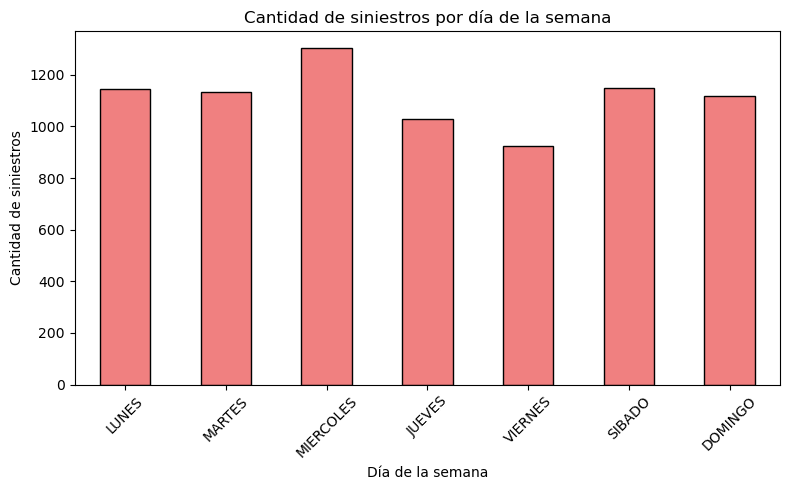

In [7]:
orden_dias = ["LUNES", "MARTES", "MIERCOLES", "JUEVES", "VIERNES", "SIBADO", "DOMINGO"]

dias_counts = df["dia de la semana"].value_counts().reindex(orden_dias)

display(dias_counts)

plt.figure(figsize=(8,5))
dias_counts.plot(kind="bar", color="lightcoral", edgecolor="black")

plt.title("Cantidad de siniestros por día de la semana")
plt.xlabel("Día de la semana")
plt.ylabel("Cantidad de siniestros")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

zona
RURAL          90
SIN DATOS      97
SUBURBANA    1231
URBANA       6384
Name: count, dtype: int64


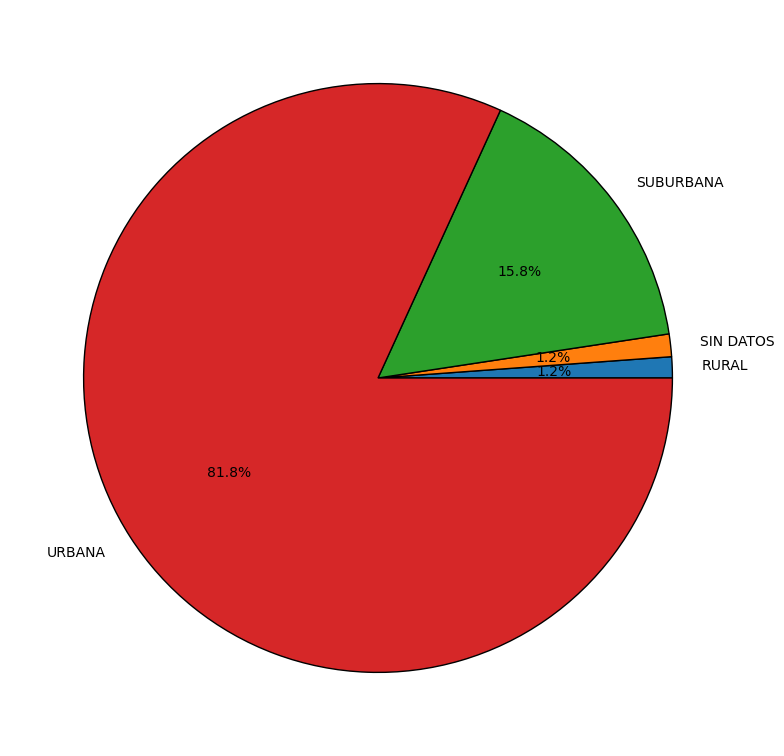

In [8]:
zona_counts = df["zona"].value_counts().sort_index()

print(zona_counts)

plt.figure(figsize=(8,8))
zona_counts.plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=0,
    wedgeprops={"edgecolor": "black"}
)

plt.ylabel("")
plt.tight_layout()
plt.savefig(f"siniestros_por_tipo.pdf", bbox_inches='tight', pad_inches=0.05)
plt.show()

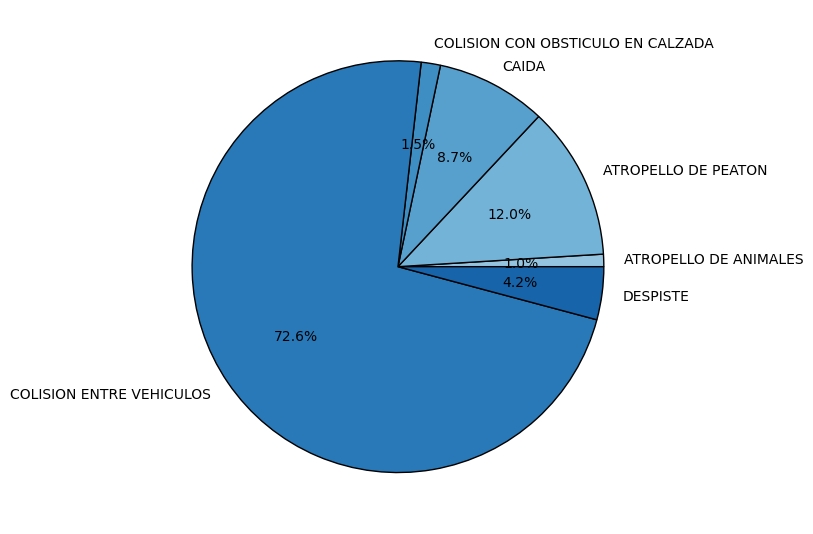

In [9]:
tipo_siniestro_counts = df["tipo de siniestro"].value_counts().sort_index()
plt.figure(figsize=(8,8))
colores = plt.cm.Blues(np.linspace(0.4, 0.8, len(tipo_siniestro_counts)))

tipo_siniestro_counts.plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=0,
    wedgeprops={"edgecolor": "black"},
    colors=colores
)

plt.ylabel("")
plt.tight_layout()
plt.savefig(f"siniestros_por_tipo.pdf", bbox_inches='tight', pad_inches=0.05)
plt.show()


Me quedo solo con los que son de colisión entre vehiculos

In [11]:
df_colision = df[df["tipo de siniestro"] == "COLISION ENTRE VEHICULOS"]
df_colision.head()

,fecha,edad,rol,calle,zona,tipo de resultado,tipo de siniestro,usa cinturin,usa casco,dia de la semana,sexo,hora,departamento,localidad,novedad,tipo de vehiculo,fixed,x,y
0,2022-01-01,37,PASAJERO,CAMINO CARMELO COLMAN,URBANA,HERIDO LEVE,COLISION ENTRE VEHICULOS,SIN DATOS,SIN DATOS,SIBADO,MASCULINO,8,MONTEVIDEO,MONTEVIDEO,14067171,AUTO,1,572280,6148440
1,2022-01-01,45,CONDUCTOR,CAMINO CARMELO COLMAN,URBANA,HERIDO LEVE,COLISION ENTRE VEHICULOS,SIN DATOS,SIN DATOS,SIBADO,MASCULINO,8,MONTEVIDEO,MONTEVIDEO,14067171,AUTO,1,572280,6148440
3,2022-01-01,31,CONDUCTOR,SIN DATOS,URBANA,HERIDO LEVE,COLISION ENTRE VEHICULOS,SIN DATOS,SIN DATOS,SIBADO,MASCULINO,23,MONTEVIDEO,SIN DATOS,14069875,AUTO,1,581650,6149845
4,2022-01-01,19,CONDUCTOR,JOANICO,URBANA,HERIDO LEVE,COLISION ENTRE VEHICULOS,SIN DATOS,NO USA CASCO,SIBADO,MASCULINO,5,MONTEVIDEO,MONTEVIDEO,14066691,MOTO,1,577450,6139860
5,2022-01-01,29,CONDUCTOR,JOANICO,URBANA,HERIDO LEVE,COLISION ENTRE VEHICULOS,SIN DATOS,USA CASCO,SIBADO,MASCULINO,5,MONTEVIDEO,MONTEVIDEO,14066691,MOTO,1,577450,6139860


In [14]:
# Cantidad que son de colision
print("Hay", len(df_colision), "datos que corresponden al tipo COLISION ENTRE VEHICULOS.")

Hay 5668 datos que corresponden al tipo COLISION ENTRE VEHICULOS.


zona
RURAL          46
SIN DATOS      55
SUBURBANA     865
URBANA       4702
Name: count, dtype: int64


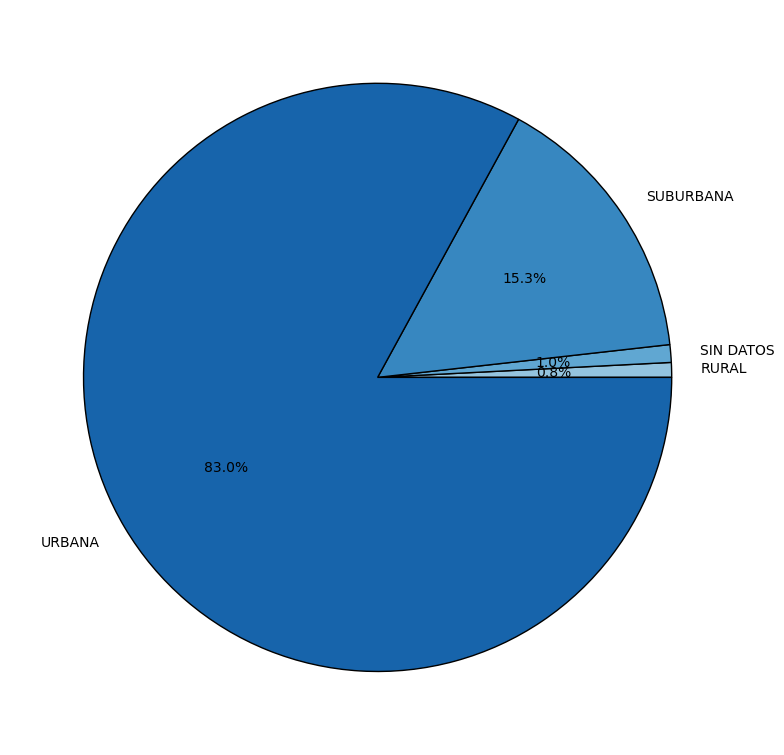

In [15]:
zona_counts = df_colision["zona"].value_counts().sort_index()

print(zona_counts)
colores = plt.cm.Blues(np.linspace(0.4, 0.8, len(zona_counts)))

plt.figure(figsize=(8,8))
zona_counts.plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=0,
    wedgeprops={"edgecolor": "black"},
    colors=colores
)

plt.ylabel("")
plt.tight_layout()
plt.savefig(f"siniestros_por_zona.pdf", bbox_inches='tight', pad_inches=0.05)
plt.show()

A partir de este momento, utilizaremos datos geográficos, por lo que convertiremos el dataframe en un geo-dataframe:

,fecha,edad,rol,calle,zona,tipo de resultado,tipo de siniestro,usa cinturin,usa casco,dia de la semana,sexo,hora,departamento,localidad,novedad,tipo de vehiculo,fixed,x,y,geometry
0,2022-01-01,37,PASAJERO,CAMINO CARMELO COLMAN,URBANA,HERIDO LEVE,COLISION ENTRE VEHICULOS,SIN DATOS,SIN DATOS,SIBADO,MASCULINO,8,MONTEVIDEO,MONTEVIDEO,14067171,AUTO,1,572280,6148440,POINT (572280 6148440)
1,2022-01-01,45,CONDUCTOR,CAMINO CARMELO COLMAN,URBANA,HERIDO LEVE,COLISION ENTRE VEHICULOS,SIN DATOS,SIN DATOS,SIBADO,MASCULINO,8,MONTEVIDEO,MONTEVIDEO,14067171,AUTO,1,572280,6148440,POINT (572280 6148440)
3,2022-01-01,31,CONDUCTOR,SIN DATOS,URBANA,HERIDO LEVE,COLISION ENTRE VEHICULOS,SIN DATOS,SIN DATOS,SIBADO,MASCULINO,23,MONTEVIDEO,SIN DATOS,14069875,AUTO,1,581650,6149845,POINT (581650 6149845)
4,2022-01-01,19,CONDUCTOR,JOANICO,URBANA,HERIDO LEVE,COLISION ENTRE VEHICULOS,SIN DATOS,NO USA CASCO,SIBADO,MASCULINO,5,MONTEVIDEO,MONTEVIDEO,14066691,MOTO,1,577450,6139860,POINT (577450 6139860)
5,2022-01-01,29,CONDUCTOR,JOANICO,URBANA,HERIDO LEVE,COLISION ENTRE VEHICULOS,SIN DATOS,USA CASCO,SIBADO,MASCULINO,5,MONTEVIDEO,MONTEVIDEO,14066691,MOTO,1,577450,6139860,POINT (577450 6139860)


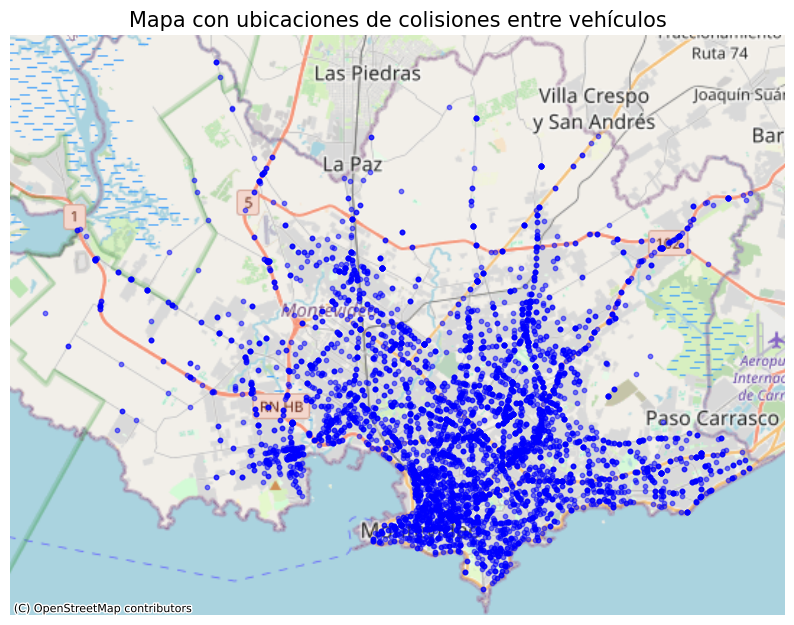

(<Figure size 1000x1000 with 1 Axes>,
 <Axes: title={'center': 'Mapa con ubicaciones de colisiones entre vehículos'}>)

In [19]:
gdf = gpd.GeoDataFrame(
    df_colision, 
    geometry=gpd.points_from_xy(df_colision['x'], df_colision['y']),
    crs="EPSG:32721"
)

display(gdf.head())
graficar_sobre_mapa(gdf, "Mapa con ubicaciones de colisiones entre vehículos", save=True)


Para reducir un poco la cantidad de datos y poder visualizar mejor, reduciremos el alcance a una zona de montevideo elegida previamente. Además, para poder utilizarlo en conjunto con el resto de los dataset, utilizaremos solo los datos de septiembre.

,fecha,edad,rol,calle,zona,tipo de resultado,tipo de siniestro,usa cinturin,usa casco,dia de la semana,sexo,hora,departamento,localidad,novedad,tipo de vehiculo,fixed,x,y,geometry
4934,2022-09-01,30,CONDUCTOR,GABRIEL PEREIRA,URBANA,HERIDO LEVE,COLISION ENTRE VEHICULOS,SIN DATOS,USA CASCO,MARTES,MASCULINO,10,MONTEVIDEO,MONTEVIDEO,15480359,MOTO,SIN DATOS,577525,6137075,POINT (577525 6137075)
4936,2022-09-01,31,PASAJERO,COLONIA,URBANA,HERIDO LEVE,COLISION ENTRE VEHICULOS,NO USA CINTURON,SIN DATOS,MARTES,FEMENINO,11,MONTEVIDEO,MONTEVIDEO,15480447,CAMIONETA,SIN DATOS,575205,6137620,POINT (575205 6137620)
4937,2022-09-01,34,PASAJERO,COLONIA,URBANA,HERIDO LEVE,COLISION ENTRE VEHICULOS,NO USA CINTURON,SIN DATOS,MARTES,FEMENINO,11,MONTEVIDEO,MONTEVIDEO,15480447,CAMIONETA,SIN DATOS,575205,6137620,POINT (575205 6137620)
4940,2022-09-01,34,PASAJERO,AVENIDA OCHO DE OCTUBRE,URBANA,HERIDO LEVE,COLISION ENTRE VEHICULOS,SIN DATOS,NO USA CASCO,MARTES,FEMENINO,13,MONTEVIDEO,MONTEVIDEO,15481479,BICICLETA,SIN DATOS,577690,6139885,POINT (577690 6139885)
4949,2022-09-01,31,CONDUCTOR,AVENIDA GONZALO RAMIREZ,URBANA,HERIDO LEVE,COLISION ENTRE VEHICULOS,SIN DATOS,USA CASCO,MARTES,FEMENINO,20,MONTEVIDEO,MONTEVIDEO,15483588,MOTO,SIN DATOS,574890,6136370,POINT (574890 6136370)


Cantidad de colisiones: 162


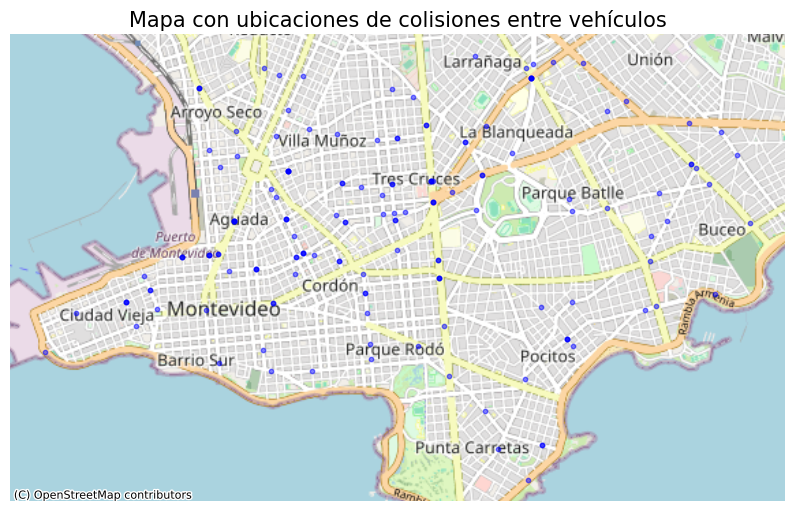

(<Figure size 1000x1000 with 1 Axes>,
 <Axes: title={'center': 'Mapa con ubicaciones de colisiones entre vehículos'}>)

In [23]:
# Filtro espacial
gdf_filtrado = gdf.cx[570000:580000, :6140000]

# Filtro de fecha
gdf_filtrado = gdf_filtrado[gdf_filtrado['fecha'].dt.month == 9]

# Mostrar y graficar
display(gdf_filtrado.head())
print("Cantidad de colisiones:", len(gdf_filtrado))
graficar_sobre_mapa(gdf_filtrado, "Mapa con ubicaciones de colisiones entre vehículos")

Con ese nuevo filtro, podríamos repetir alguno de los análisis anteriores:

Cantidad de colisiones: 162


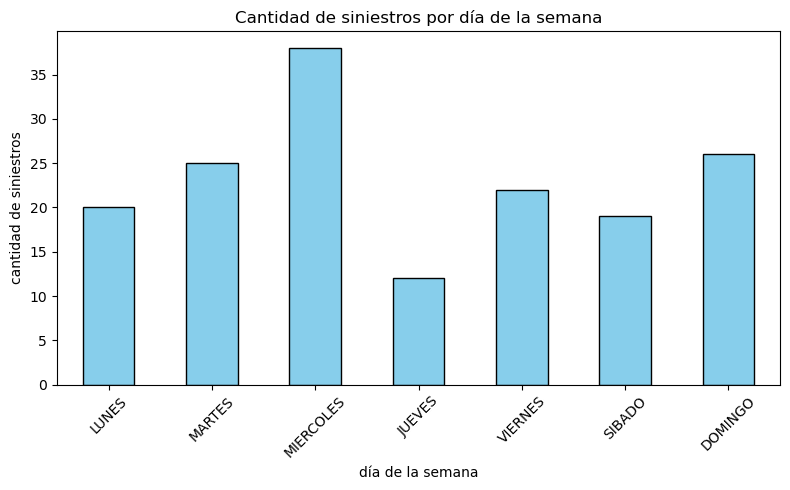

In [24]:
dias_counts = gdf_filtrado['dia de la semana'].value_counts()

# Definimos el orden correcto de días
orden_semana = ['LUNES', 'MARTES', 'MIERCOLES', 'JUEVES', 'VIERNES', 'SIBADO', 'DOMINGO']

# Reordenamos los resultados
dias_counts = dias_counts.reindex(orden_semana)

# Grafico
print("Cantidad de colisiones:", len(gdf_filtrado))

plt.figure(figsize=(8,5))
dias_counts.plot(kind="bar", color="skyblue", edgecolor="black")
plt.title("Cantidad de siniestros por día de la semana")
plt.xlabel("día de la semana")
plt.ylabel("cantidad de siniestros")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [25]:
# df_filtrado.to_csv("siniestros_filtrados.csv", index=False)
